### Functions and Libraries

In [2]:
import pandas as pd
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
from pyspark.ml.feature import PCA

#libs de datascience para spark
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder

from pyspark.ml.clustering import KMeans

### Spark Session

In [3]:
spark = SparkSession.builder.appName("Olist Customer Segmentation").getOrCreate()

### DataSet

In [4]:
# 📦 Leitura dos arquivos CSV da Olist
CUSTOMERS         = spark.read.csv("dataset/olist_customers_dataset.csv",            header=True, inferSchema=True)
ORDERS            = spark.read.csv("dataset/olist_orders_dataset.csv",               header=True, inferSchema=True)
ORDER_ITEMS       = spark.read.csv("dataset/olist_order_items_dataset.csv",          header=True, inferSchema=True)
PAYMENTS          = spark.read.csv("dataset/olist_order_payments_dataset.csv",       header=True, inferSchema=True)
REVIEWS           = spark.read.csv("dataset/olist_order_reviews_dataset.csv",        header=True, inferSchema=True)
PRODUCTS          = spark.read.csv("dataset/olist_products_dataset.csv",             header=True, inferSchema=True)
GEOLOCATION       = spark.read.csv("dataset/olist_geolocation_dataset.csv",          header=True, inferSchema=True)
PRODUCT_CATEGORY  = spark.read.csv("dataset/product_category_name_translation.csv",  header=True, inferSchema=True)


## Data Modelling and Data Cleaning

### Dataframes Core

In [5]:
#Dataframe de ordens
orders_df = (
    ORDERS
    .select("order_id", "customer_id", "order_purchase_timestamp", "order_delivered_customer_date")
)

#Dataframe com a contagem de ordens por clientes
orders_per_customer_df = (
    orders_df
    .groupBy("customer_id")
    .agg(
        F.count("order_id").alias("num_orders")
    )
)

orders_items_payments_df = (
    ORDER_ITEMS
    .join(ORDERS, "order_id")
    .join(PAYMENTS, "order_id")
    .groupBy("customer_id")
    .agg(
        F.sum("price").alias("total_price"),
        F.sum("freight_value").alias("total_freight"),
        F.countDistinct("payment_type").alias("payment_type_count")
    )
)

#Média de reviews por clientes
reviews_avg_df = (
    REVIEWS
    .join(ORDERS, "order_id") 
    .groupBy("customer_id") 
    .agg(F.avg("review_score").alias("avg_review_score"))
)

#Tempo médio de entrega por cliente
orders_delivery_time_df = (
    ORDERS
    .withColumn("delivery_days", F.datediff("order_delivered_customer_date", "order_purchase_timestamp"))
    .select("customer_id", "delivery_days")
    .groupBy("customer_id")
    .agg(F.avg("delivery_days").alias("avg_delivery_days"))
)

### Dataframe Final

In [6]:
customers_df = (
    CUSTOMERS # 99.441 linhas
    .join(orders_per_customer_df, on = 'customer_id', how = "inner") # 99.441 linhas
    .join(orders_items_payments_df, on = 'customer_id', how = "left") 
    .join(reviews_avg_df, on = 'customer_id', how = "left") 
    .join(orders_delivery_time_df, on = 'customer_id', how = "left") 
)

# Indexadores
city_indexer = StringIndexer(inputCol="customer_city", outputCol="customer_city_index")
state_indexer = StringIndexer(inputCol="customer_state", outputCol="customer_state_index")

# Aplicar os indexadores
customers_df = city_indexer.fit(customers_df).transform(customers_df)
customers_df = state_indexer.fit(customers_df).transform(customers_df)

# One-Hot Encoders
city_encoder = OneHotEncoder(inputCol="customer_city_index", outputCol="customer_city_ohe")
state_encoder = OneHotEncoder(inputCol="customer_state_index", outputCol="customer_state_ohe")

# Aplicar os encoders
customers_df = city_encoder.fit(customers_df).transform(customers_df)
customers_df = state_encoder.fit(customers_df).transform(customers_df)

In [5]:
customers_df = (
    CUSTOMERS # 99.441 linhas
    .join(orders_per_customer_df, on = 'customer_id', how = "inner") # 99.441 linhas
    .join(orders_items_payments_df, on = 'customer_id', how = "left") 
    .join(reviews_avg_df, on = 'customer_id', how = "left") 
    .join(orders_delivery_time_df, on = 'customer_id', how = "left") 
)

# Indexadores
city_indexer = StringIndexer(inputCol="customer_city", outputCol="customer_city_index")
state_indexer = StringIndexer(inputCol="customer_state", outputCol="customer_state_index")

# Aplicar os indexadores
customers_df = city_indexer.fit(customers_df).transform(customers_df)
customers_df = state_indexer.fit(customers_df).transform(customers_df)

# One-Hot Encoders
city_encoder = OneHotEncoder(inputCol="customer_city_index", outputCol="customer_city_ohe")
state_encoder = OneHotEncoder(inputCol="customer_state_index", outputCol="customer_state_ohe")

# Aplicar os encoders
customers_df = city_encoder.fit(customers_df).transform(customers_df)
customers_df = state_encoder.fit(customers_df).transform(customers_df)

display(customers_df.toPandas())

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,num_orders,total_price,total_freight,payment_type_count,avg_review_score,avg_delivery_days,customer_city_index,customer_state_index,customer_city_ohe,customer_state_ohe
0,e3c7e245a96d7fa339fe6c16f8da4e90,79051ee5ee98c4bd6982e67e2e79dbcb,7847,franco da rocha,SP,1,388.50,27.47,1.0,5.0,8.0,129.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,a56b03f5e6015f1a502b9810309b98b7,b6cbe1a8674ee23e9fb086e3c61677b8,41308,salvador,BA,1,99.80,39.18,2.0,5.0,16.0,7.0,6.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ..."
2,d0615859a639a94c1fe472eba57d4a7c,9072b46e3b68961565477d90b24092e9,12900,braganca paulista,SP,1,59.00,7.71,1.0,4.0,4.0,93.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,c0fe0fbc24994167dce810f83cb96890,839bbfd4ff93b592c82a44dcaa9515c3,30330,belo horizonte,MG,1,48.89,15.10,1.0,5.0,25.0,2.0,2.0,"(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,5b5f4957a69d537a2aeadfa7dd2d09d9,bb03ed8d9549898e869f0e6774064096,71505,brasilia,DF,1,135.90,29.35,1.0,5.0,13.0,3.0,7.0,"(0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,2fe41af4567a61030ca34a12594e0316,b24c2da84afc32beb53ace42670b8aa4,30170,belo horizonte,MG,1,629.00,49.08,1.0,5.0,9.0,2.0,2.0,"(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
99437,72f4681642ad6cbcfcb011920336f1d7,e03d7002d4845a2d2e38d8b89305bb0f,15903,guariroba,SP,1,120.00,14.27,1.0,1.0,8.0,2555.0,0.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
99438,1e3252b73d8c7d66a3e003069691c85e,6e798f3815f0984effe9a64aa821718a,28970,araruama,RJ,1,59.90,16.18,1.0,5.0,17.0,182.0,1.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
99439,6e62287af5611e444bfec7acf45c8476,e9ffbd035ad1dac5ff0204abb377b73f,52020,recife,PE,1,129.00,19.59,1.0,5.0,11.0,18.0,10.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [6]:
# EDA para encontrar valores nulos
null_counts = (
    customers_df
    .select([
        F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in customers_df.columns
    ])
)

display(null_counts.toPandas())

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,num_orders,total_price,total_freight,payment_type_count,avg_review_score,avg_delivery_days,customer_city_index,customer_state_index,customer_city_ohe,customer_state_ohe
0,0,0,0,0,0,0,776,776,776,768,2965,0,0,0,0


In [7]:
customers_df = (
    customers_df.na.fill(0)
    .drop('customer_city_index', 'customer_state_index')
)

## Clusterização de Dados

In [8]:
assembler = VectorAssembler(
    inputCols=customers_df.columns[5:],
    outputCol="features"
)

assembled = assembler.transform(customers_df)

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True, 
    withMean=True 
)

scaled_model = scaler.fit(assembled)
scaled_data = scaled_model.transform(assembled)

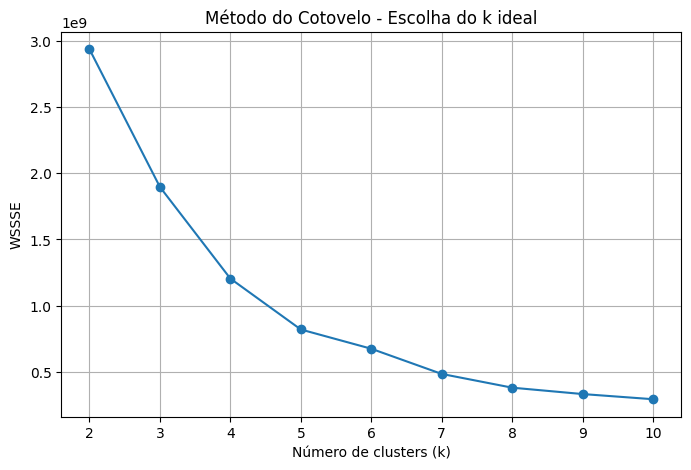

In [12]:
# Testando vários valores de k
cost = []
ks = list(range(2, 11))  # k de 2 a 10

for k in ks:
    kmeans = KMeans(k=k, seed=1, featuresCol='features')
    model = kmeans.fit(assembled)
    wssse = model.summary.trainingCost
    cost.append(wssse)

# Plotando o gráfico
plt.figure(figsize=(8, 5))
plt.plot(ks, cost, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WSSSE')
plt.title('Método do Cotovelo - Escolha do k ideal')
plt.grid(True)
plt.show()

In [9]:
kmeans = KMeans(featuresCol="scaled_features", k=5, seed=1)
model = kmeans.fit(scaled_data)
clustered = model.transform(scaled_data)

In [11]:
# 1. Redução de dimensionalidade com PCA
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(clustered)
pca_result = pca_model.transform(clustered)

# 2. Seleciona apenas as colunas necessárias
pca_pd = (
    pca_result
    .select("pca_features", "prediction")
    .rdd
    .map(lambda row: (float(row.pca_features[0]), float(row.pca_features[1]), row.prediction))
    .toDF(["x", "y", "cluster"])
    .toPandas()
)

# 3. Visualização com matplotlib
plt.figure(figsize=(10, 6))
for cluster_id in pca_pd['cluster'].unique():
    cluster_data = pca_pd[pca_pd['cluster'] == cluster_id]
    plt.scatter(cluster_data['x'], cluster_data['y'], label=f"Cluster {cluster_id}", alpha=0.6)

plt.title("Visualização dos Clusters com PCA (2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Py4JJavaError: An error occurred while calling o490.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 1 in stage 222.0 failed 1 times, most recent failure: Lost task 1.0 in stage 222.0 (TID 482) (172.16.3.194 executor driver): java.lang.OutOfMemoryError: Java heap space

Driver stacktrace:
	at org.apache.spark.scheduler.DAGScheduler.failJobAndIndependentStages(DAGScheduler.scala:2844)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:2780)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:2779)
	at scala.collection.mutable.ResizableArray.foreach(ResizableArray.scala:62)
	at scala.collection.mutable.ResizableArray.foreach$(ResizableArray.scala:55)
	at scala.collection.mutable.ArrayBuffer.foreach(ArrayBuffer.scala:49)
	at org.apache.spark.scheduler.DAGScheduler.abortStage(DAGScheduler.scala:2779)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1(DAG